### Preprocessing Steps:-
1. Business understand
2. Data understanding
3. Drop non-intersing features
4. check dtypes
5. handle dtypes
6. check nulls
7. handle nulls
8. check outliers
9. handle outliers
10. check duplications
11. handle duplications
12. Data visualization
    - Dashboards
    - Distributions
13. Data spliting
14. Normalization
15. Encoding

In [127]:
import pandas as pd

In [128]:
df = pd.read_csv('Titanic.csv')
type(df)

pandas.DataFrame

In [129]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [130]:
print(df.head())
print(df.tail())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

# 3. Drop non-intersting features

In [131]:
# we don't need passengerId, name, and ticket. So we will drop them
df.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)

In [132]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [133]:
# converting df.drop() to a function
def drop_cols(df, cols):
    return df.drop(columns=cols)

In [134]:
#rereading
df = pd.read_csv("Titanic.csv")

In [135]:
cols = ['PassengerId', 'Name', 'Ticket']
df = drop_cols(df, cols)

In [136]:
# we can even make a config.py file and import form it, if every time the file has these columns
# df = pd.read_csv("Titanic.csv")
# from config import COLS_DROP
# from preprocessing import drop_cols
# drop_cols(df, COLS_DROP)

# 4. Check Dtypes

In [137]:
dtypes = df.dtypes
nunique = df.nunique()
pd.DataFrame({"dtypes": dtypes, "nunique": nunique}).T
# from this we can conclude that survived, pclass, sibsp, parch, embarked, and sex, their dtypes need to be changed

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,int64,int64,str,float64,int64,int64,float64,str,str
nunique,2,3,2,88,7,7,248,147,3


In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    str    
 8   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


# 5. Handle dtypes

In [139]:
# cat for categorical
cat_cols = ['Survived', "Pclass", "Sex", "SibSp", "Parch", "Embarked"]
df[cat_cols] = df[cat_cols].astype("category")


In [140]:
dtypes = df.dtypes
nunique = df.nunique()
pd.DataFrame({"dtypes": dtypes, "nunique": nunique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,category,category,category,float64,category,category,float64,str,category
nunique,2,3,2,88,7,7,248,147,3


In [141]:
def get_type_info(df):
    return pd.DataFrame({"dtypes": df.dtypes, "nunique": df.nunique()}).T

In [142]:
get_type_info(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,category,category,category,float64,category,category,float64,str,category
nunique,2,3,2,88,7,7,248,147,3


In [143]:
df.select_dtypes("category")

,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0,3,male,1,0,S
1,1,1,female,1,0,C
2,1,3,female,0,0,S
3,1,1,female,1,0,S
4,0,3,male,0,0,S
...,...,...,...,...,...,...
886,0,2,male,0,0,S
887,1,1,female,0,0,S
888,0,3,female,1,2,S
889,1,1,male,0,0,C


# 6. Check Nulls
# 7. Handle Nulls

In [144]:
null = df.isnull().sum()
print(null)
ratio = (null / 891) * 100
ratio

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

In [145]:
# for example you're in a company and want to decide from the three cols: age, cabine, and embarked
# most of values exist (about 30%) use the mode in case of a categorical data
# otherwise, if most of the data is missing, drop the column
# embarked has only 2 rows that has missing values, you can use the mode, or drop the two rows
# you can even link a column by another column and  produce a prdiction according to the other linked columns

In [146]:
df = df.dropna(subset=['Embarked'])

In [147]:
df = df.drop("Cabin", axis = 1)

In [148]:
df.describe()
median = df['Age'].median()
print(median)

28.0


In [149]:
df['Age'] = df['Age'].fillna(median, inplace= True)

C:\Users\OC\AppData\Local\Temp\ipykernel_18412\2753167490.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(median, inplace= True)


In [150]:
null = df.isnull().sum()
ratio = (null / 891) * 100
pd.DataFrame({"null": null, "ratio": ratio})

,null,ratio
Survived,0,0.0
Pclass,0,0.0
Sex,0,0.0
Age,0,0.0
SibSp,0,0.0
Parch,0,0.0
Fare,0,0.0
Embarked,0,0.0


# 8. Check Outliers
# 9. Handle Outliers

IQR for handling outliers
it draws the safe zone of the data 


In [151]:
num_col = df.select_dtypes("number").columns
num_col
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    print(Q1, Q3)
    IQR = Q3 - Q1
    print("IQR:", IQR)
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    print(lower_fence, upper_fence)

22.0 35.0
IQR: 13.0
2.5 54.5
7.8958 31.0
IQR: 23.1042
-26.7605 65.6563


In [152]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [153]:
# import pandas as pd
# df = pd.read_csv('Titanic.csv')

# # def read_file(file_path):
# #     return pd.read_csv(file_path)
# #or
# def read_file(file_path):
#     df = pd.read_csv(file_path)
#     return df.head()


In [154]:
num_cols = df.select_dtypes("number").columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    print(f"Q1:{Q1}\nQ3:{Q3}\n")
    IQR = Q3 - Q1
    lower_fence = Q1 - (1.5 * IQR)
    upper_fence = Q3 + (1.5 * IQR)
    print(f"Lower Fence: {lower_fence}\n")
    lower_outliers = df[df[col] < lower_fence][col].values
    print(f"Lower Outliers: {lower_outliers}")
    print(f"Upper Fence: {upper_fence}\n")
    upper_outliers = df[df[col] > upper_fence][col].values
    print(f"Upper Outliers: {upper_outliers}")

    #one method of handling outliers is to replace the outliers by the fence, but this is not a good practice
    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)

    


Q1:22.0
Q3:35.0

Lower Fence: 2.5

Lower Outliers: [2.   2.   0.83 2.   1.   1.   1.   2.   2.   0.92 2.   1.   1.   0.75
 2.   2.   2.   0.75 0.67 1.   0.42 2.   1.   0.83]
Upper Fence: 54.5

Upper Outliers: [58.  55.  66.  65.  59.  71.  70.5 55.5 61.  56.  58.  59.  62.  58.
 63.  65.  61.  60.  64.  65.  56.  63.  58.  55.  71.  64.  62.  62.
 60.  61.  57.  80.  56.  58.  70.  60.  60.  70.  57.  74.  56. ]
Q1:7.8958
Q3:31.0

Lower Fence: -26.7605

Lower Outliers: []
Upper Fence: 65.6563

Upper Outliers: [ 71.2833 263.     146.5208  82.1708  76.7292  83.475   73.5    263.
  77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55    69.55
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      79.2
  86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85    91.0792
 151.55   247.5208 151.55   110.8833 108.9     83.1583 262.375  164.8667
 134.5     69.55   135.6333 153.4625 133.65    66.6    134.5    263.
  75.25    69.3    135.6333  82.1708 211.5    227.525   73.5

In [155]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.000562,23.956061
std,12.051609,20.414997
min,2.500000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,54.500000,65.656300


In [ ]:
pip install matplotlib
pip install seaborn

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ------------------- ------------------ 41.0/80.3 kB 991.0 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 752.9 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ----------------------------------- -- 112.6/121.0 kB 6.4 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 2.4 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
    --------------------------------------- 0.2/9.3 MB 5.1 MB/s eta 0:00:02
   - -------------------------------------- 0.4/9.3 MB 4.4 MB/s eta 0:00:03
   -- -----------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


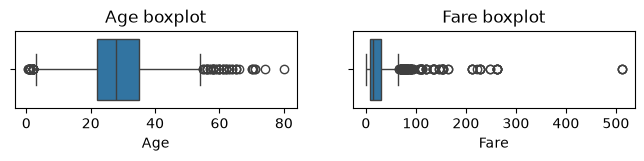

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 1))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(df[col], orient='h')
    plt.title(f"{col} boxplot")


if the outliers is valid: we keep it\
if the outliers is Invalid: we fix it\
if the outliers is unknown: we try to find the best solution

Methods to handle the outliers:
1. median
2. mean
3. winsorize(clipping) this means replacing with fence
4. nan
5. remove

In [156]:
def replace_outliers(df):
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - (1.5 * IQR)
        upper_fence = Q3 + (1.5 * IQR)

        df[col] = df[col].clip(lower_fence, upper_fence)
    return df

In [157]:
df = replace_outliers(df)

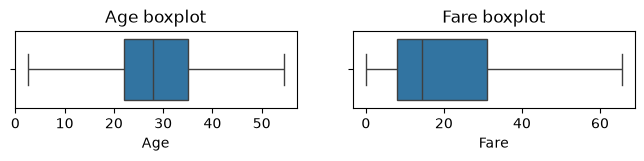

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 1))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(df[col], orient='h')
    plt.title(f"{col} boxplot")

to find the outliers we have 3 algorithms:
1. IQR
2. Z-score
3. MAD ( Median Absolute Deviation)

In [159]:
def handle_outliers(df, alg="IQR", treatment="median", multi=""):
    pass

# 10. Check Duplications
# 11. Handle Duplications

In [160]:
print(df.duplicated().sum())

129


In [161]:
df.drop_duplicates(inplace=True)


In [162]:
df.duplicated().sum()

np.int64(0)

In [163]:
def remove_duplicates(df, subset_col = None, keep_strategy = "first"):
    return (df.drop_duplicates(subset = subset_col, keep = keep_strategy).reset_index(drop = True))

### Types of graph:
1. Data Distribution
2. outlier distribution
3. Relationship Graph

### Numerical Data:
1. Histogram 
2. KDE plot

### Categorical Data:
1. count plot
2. pie plot


In [164]:
num_cols

Index(['Age', 'Fare'], dtype='str')

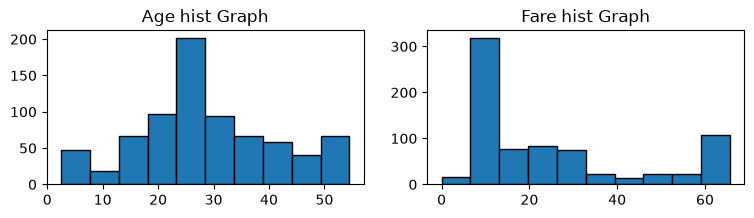

In [165]:
plt.figure(figsize=(9, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist Graph")
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'kdeplot'

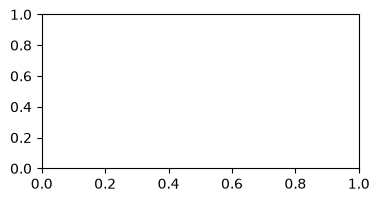

In [166]:
plt.figure(figsize=(9, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    plt.kdeplot(df[col],)
    plt.title(f"{col} hist Graph")
plt.show()

A histogram counts while the KDE normalizes the histogram

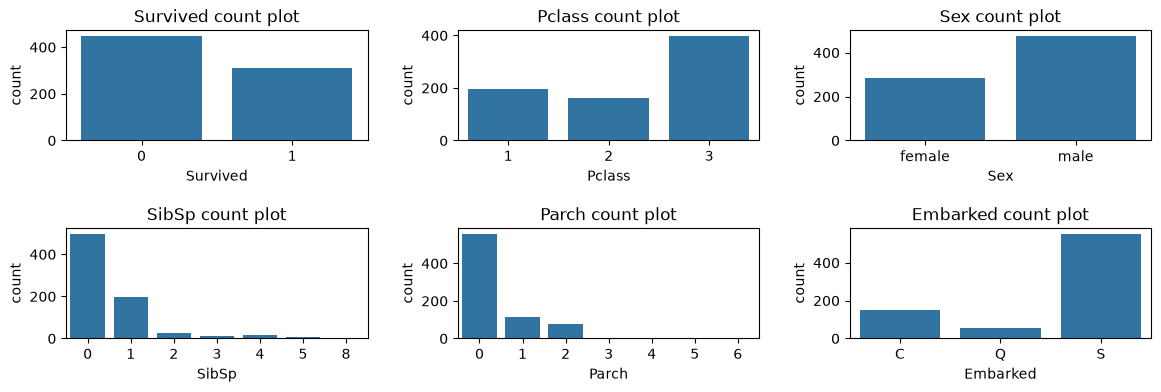

In [171]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} count plot")
plt.subplots_adjust(hspace = 0.8, wspace = 0.3)
plt.show()

In [177]:
print(cat_cols)
unique = df['Survived'].value_counts()
counts = unique.values
categories = unique.index
categories

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')


CategoricalIndex([0, 1], categories=[0, 1], ordered=False, dtype='category', name='Survived')

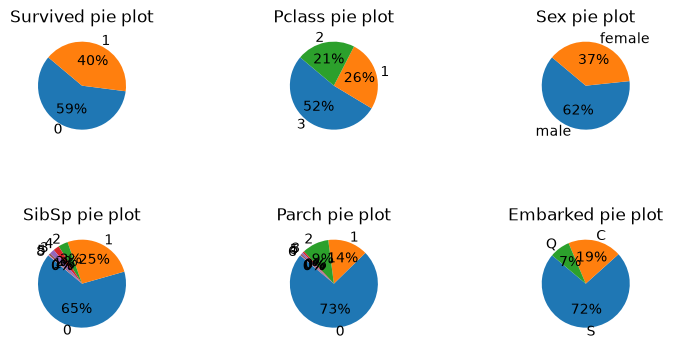

In [183]:
plt.figure(figsize= (9, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    unique = df[col].value_counts()
    counts = unique.values
    categories = unique.index 
    plt.pie(counts, labels = categories, startangle= 140, autopct = '%1.1d%%')
    plt.title(f"{col} pie plot")
plt.subplots_adjust(hspace = 0.8, wspace = 0.3)
plt.show()    

In the relationship graph, if the columns are:\
num, num -> scatter plot, pairplot, heatmap, lion plot\
cat, num -> bar plot\
cat, cat -> heatmap


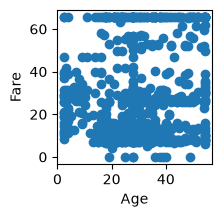

In [184]:
plt.figure(figsize= (2, 2))
plt.scatter(df['Age'], df['Fare'])
plt.xlabel("Age")
plt.ylabel('Fare')
plt.show()


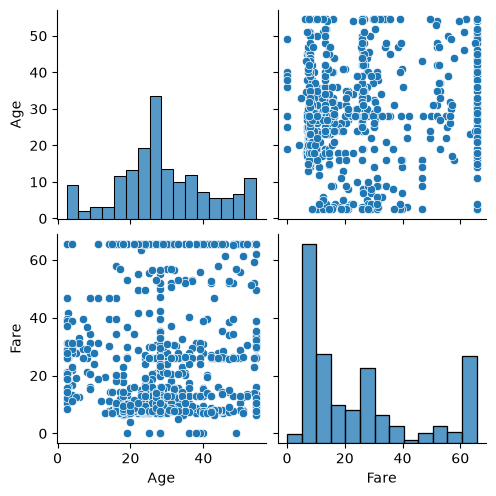

In [185]:
sns.pairplot(df)

<Axes: >

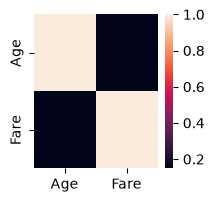

In [190]:
corr = df.corr(numeric_only= True)
plt.figure(figsize = (2, 2))
sns.heatmap(corr)
